In [1]:
import numpy as np
import pandas as pd

df = pd.read_csv('C:/Users/fedor/fluent_python/ab_data.csv')
df.head()

,user_id,group,converted,revenue,time_sec,clicks,sessions,device
0,A_000,A,0,0.00,42.6,4,2,mobile
1,A_001,A,1,133.77,71.1,2,2,mobile
2,A_002,A,0,0.00,73.3,6,1,mobile
3,A_003,A,0,0.00,47.6,3,1,mobile
4,A_004,A,0,0.00,48.9,0,5,desktop


In [2]:
# SRM (Sample Ratio Mismatch) → проверка соответствия фактического соотношения групп ожидаемому (критерий χ²)
# Являются ли группы для A/B теста одинаковыми по размеру
from scipy.stats import chisquare

observed = df['group'].value_counts().sort_index()
print(f'observed: {observed}')

# Формулируем H0, то есть делаем одинаковые группы по количеству наблюдений
# Но если бы дизайн эксперимента был бы другой, можно сделать и группы разных размеров
expected = [df.shape[0] / 2, df.shape[0] / 2]  
chi2, p = chisquare(f_obs=observed.values, f_exp=expected)

print(f"chi2 = {chi2:.4f}, p = {p:.4f}")

observed: group
A    60
B    60
Name: count, dtype: int64
chi2 = 0.0000, p = 1.0000


In [9]:
# Если два уникальных значения-метрика бинарная, если больше двух-категориальная
print("Дубли user_id:", df['user_id'].duplicated().sum())
print("Пропуски:", df.isna().sum().sum())
print("Уникальные device:", df['device'].unique())
print("Значения:", df['device'].value_counts().to_dict())

Дубли user_id: 0
Пропуски: 0
Уникальные device: ['mobile' 'desktop' 'tablet']
Значения: {'mobile': 69, 'desktop': 40, 'tablet': 11}


In [12]:
# Смотрим сколько в каждой ячейке
# Доли mobile / desktop / tablet в A и B — похожи или разные?
# Есть ли категории с очень маленькими числами (< 5)?
import pandas as pd
tab = pd.crosstab(df['group'], df['device'])
print(tab)

device  desktop  mobile  tablet
group                          
A            19      39       2
B            21      30       9


In [13]:
# Доли в B сдвинулись относительно A? (например, desktop стало больше)
# Разница визуально есть или «шум»?
tab_pct = pd.crosstab(df['group'], df['device'], normalize='index')
print((tab_pct * 100).round(1))

device  desktop  mobile  tablet
group                          
A          31.7    65.0     3.3
B          35.0    50.0    15.0


In [ ]:
# Здесь таблица r×c (3 категории × 2 группы = 6 ячеек). 
# Для χ² r×c правило: не более 20% ячеек с Expected < 5 и ни одной с Expected < 1. 
# Если нарушено — объединяем редкие категории или используем Фишер.

from scipy.stats import chi2_contingency

chi2, p, dof, expected = chi2_contingency(tab, correction=False)
expected_df = pd.DataFrame(expected, index=tab.index, columns=tab.columns)
print(expected_df.round(2))
print(f"\nmin(Expected) = {expected.min():.2f}")

device  desktop  mobile  tablet
group                          
A          20.0    34.5     5.5
B          20.0    34.5     5.5

min(Expected) = 5.50


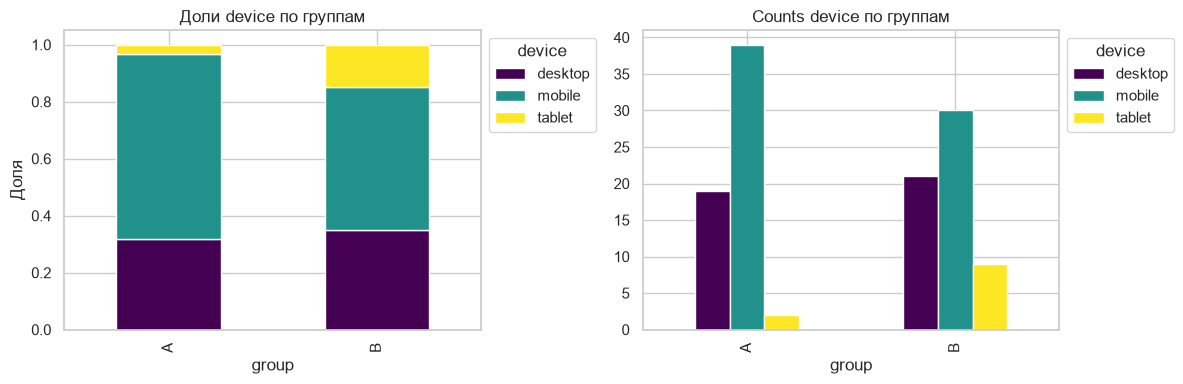

In [17]:
# Смотрим различия в форме столбиков между A и B.
# Не «уезжает» ли одна из категорий заметно.

import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Stacked barplot (доли)
tab_pct.plot(kind='bar', stacked=True, ax=axes[0], colormap='viridis')
axes[0].set_title('Доли device по группам')
axes[0].set_ylabel('Доля')
axes[0].legend(title='device', bbox_to_anchor=(1, 1))

# Grouped barplot (абсолютные)
tab.plot(kind='bar', ax=axes[1], colormap='viridis')
axes[1].set_title('Counts device по группам')
axes[1].legend(title='device', bbox_to_anchor=(1, 1))

plt.tight_layout()
plt.show()

In [19]:
# Если все значения в таблице r x c ≥ 5:
from scipy.stats import chi2_contingency

# Формально: не отвергаем H₀ «распределение device одинаково в A и B»
chi2, p, dof, expected = chi2_contingency(tab, correction=False)
print(f"chi2 = {chi2:.4f}, dof = {dof}, p = {p:.4f}")

chi2 = 5.7285, dof = 2, p = 0.0570


In [22]:
# Стандартизированные остатки
# Смысл: остаток показывает, насколько ячейка отклонилась от ожидания в «сигмах». Похоже на z-оценку
residuals = (tab - expected) / np.sqrt(expected)
print(residuals.round(2))

# Аналогично правилу для z-оценок: |z| > 1.96 — на грани значимости при α = 0.05.
# |residual|	Что означает
# < 2	        ячейка «в норме» — соответствует H₀
# 2–3	        умеренное отклонение, стоит внимания
# > 3	        сильное отклонение — здесь и сидит эффект

device  desktop  mobile  tablet
group                          
A         -0.22    0.77   -1.49
B          0.22   -0.77    1.49


In [23]:
print("""

Вывод: χ² дал p = 0.057 не из-за одной ячейки, а из-за сложения мелких отклонений (mobile + tablet). 
Если бы tablet имел |res| > 3 — можно было бы говорить «эффект в tablet». 
У нас — «эффект размазан по нескольким категориям, и в целом всё ещё в пределах шума».

""")



Вывод: χ² дал p = 0.057 не из-за одной ячейки, а из-за сложения мелких отклонений (mobile + tablet). 
Если бы tablet имел |res| > 3 — можно было бы говорить «эффект в tablet». 
У нас — «эффект размазан по нескольким категориям, и в целом всё ещё в пределах шума».


